# NB5 — LSTM + Attention Fusion Model

**Prerequisites (all must be done before running this notebook):**
- `NB1_Setup_and_Data.ipynb` — datasets downloaded to Drive
- `NB2_Feature_Extraction.ipynb` — `nthu_features.csv` saved to Drive
- `NB3_IR_CNN.ipynb` — `ir_cnn.h5` saved to Drive
- `NB4_RGB_CNN.ipynb` — `rgb_cnn.keras` (or legacy `rgb_cnn.h5`) saved to Drive

**Steps covered:**
1. Restore `nthu_features.csv` from Drive
2. Load IR CNN and RGB CNN
   *(3-strategy Keras 3.x-safe loader — handles both `.keras` and legacy `.h5`)*
3. Build LSTM model (30-frame sliding window, 5-feature input)
4. Create sequences from feature CSV → train LSTM
5. Build Attention Fusion model (RGB 256-dim + IR 128-dim + LSTM 64-dim → 3-class)
6. Extract real features from NTHU-DDD → train Fusion model
7. Visualise learned attention weights (day vs night)

> Saves `lstm.h5` and `fusion.h5` to `MyDrive/drowsiness/models/`

---

In [1]:
# Install packages (run once per Colab session)
# tf_keras provides the legacy Keras 2 API needed to load MobileNetV3 .h5 files
!pip install -q kagglehub mediapipe opencv-python-headless \
    imbalanced-learn tqdm seaborn tf_keras "protobuf>=5.26.1,<6.0.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.5 MB/s eta 0:00:00


In [2]:
# Common imports
import os, shutil, tarfile, time, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU:', gpus[0].name)
else:
    print('WARNING: No GPU — go to Runtime > Change runtime type > T4 GPU')
print('TensorFlow:', tf.__version__)


GPU: /physical_device:GPU:0
TensorFlow: 2.19.0


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Auto-detect the 'drowsiness' folder ──────────────────────────────────────
# Checks:  MyDrive  →  Shareddrives  →  error with clear instructions
#
# IMPORTANT — If your 'drowsiness' folder is in "Shared with me":
#   Colab CANNOT access "Shared with me" folders directly.
#   You must first add it as a shortcut to your My Drive:
#     1. Open Google Drive → "Shared with me"
#     2. Right-click the 'drowsiness' folder
#     3. Click "Organize" → "Add shortcut" → "My Drive" → Add
#   After that, re-run this cell and it will be found automatically.

def find_drive_root(folder_name='drowsiness'):
    # 1. Personal My Drive (also picks up shortcuts added from Shared with me)
    candidate = f'/content/drive/MyDrive/{folder_name}'
    if os.path.isdir(candidate):
        print(f'[OK] Found in My Drive: {candidate}')
        return candidate

    # 2. Shared Drives (Google Workspace / Team Drives)
    shared_base = '/content/drive/Shareddrives'
    if os.path.isdir(shared_base):
        for drive_name in sorted(os.listdir(shared_base)):
            candidate = os.path.join(shared_base, drive_name, folder_name)
            if os.path.isdir(candidate):
                print(f'[OK] Found in Shared Drive "{drive_name}": {candidate}')
                return candidate

    # 3. Not found — show helpful instructions
    my_drive_contents = []
    try:
        my_drive_contents = os.listdir('/content/drive/MyDrive')
    except Exception:
        pass
    raise FileNotFoundError(
        f"\n\n'drowsiness' folder not found in your Google Drive!\n"
        f"\nYour My Drive contains: {my_drive_contents}\n"
        f"\nFix (if your folder is in 'Shared with me'):\n"
        f"  1. Open Google Drive -> 'Shared with me'\n"
        f"  2. Right-click 'drowsiness' folder\n"
        f"  3. Click 'Organize' -> 'Add shortcut' -> 'My Drive' -> Add\n"
        f"  4. Re-run this cell\n"
    )

DRIVE_ROOT    = find_drive_root('drowsiness')
MODEL_DIR     = DRIVE_ROOT + '/models'
DATASET_DIR   = DRIVE_ROOT + '/datasets'
LOCAL_DS_ROOT = '/content/datasets'

for d in [MODEL_DIR, DATASET_DIR, LOCAL_DS_ROOT]:
    os.makedirs(d, exist_ok=True)

nthu_path         = os.path.join(LOCAL_DS_ROOT, 'nthu_ddd')
IR_MODEL_PATH     = os.path.join(MODEL_DIR, 'ir_cnn.h5')
RGB_MODEL_KERAS   = os.path.join(MODEL_DIR, 'rgb_cnn.keras')
RGB_MODEL_H5      = os.path.join(MODEL_DIR, 'rgb_cnn.h5')
LSTM_MODEL_PATH   = os.path.join(MODEL_DIR, 'lstm.h5')
FUSION_MODEL_PATH = os.path.join(MODEL_DIR, 'fusion.h5')
CSV_PATH          = '/content/nthu_features.csv'
CSV_DRIVE_PATH    = os.path.join(MODEL_DIR, 'nthu_features.csv')
FACE_LANDMARKER_LOCAL = '/content/face_landmarker.task'
FACE_LANDMARKER_DRIVE = os.path.join(MODEL_DIR, 'face_landmarker.task')
EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

print()
print('Files in MODEL_DIR:')
for f in sorted(os.listdir(MODEL_DIR)):
    size_mb = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024**2
    print(f'  {f:<30}  {size_mb:.1f} MB')


Mounted at /content/drive
[OK] Found in My Drive: /content/drive/MyDrive/drowsiness

Files in MODEL_DIR:
  face_landmarker.task            3.6 MB
  ir_cnn.h5                       1.3 MB
  lstm.h5                         1.4 MB
  nthu_features.csv               3.3 MB
  rgb_cnn.h5                      5.0 MB
  rgb_cnn.keras                   4.7 MB


In [4]:
# ── Auto-mount Drive if not already mounted ───────────────────────────────────
if not os.path.exists('/content/drive/MyDrive'):
    print('Drive not mounted — mounting now ...')
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

# ── Restore feature CSV ───────────────────────────────────────────────────────
if not os.path.isfile(CSV_PATH):
    if os.path.isfile(CSV_DRIVE_PATH):
        shutil.copy(CSV_DRIVE_PATH, CSV_PATH)
        print('Restored nthu_features.csv from Drive')
    else:
        if os.path.isdir(MODEL_DIR):
            drive_files = os.listdir(MODEL_DIR)
        else:
            drive_files = ['MODEL_DIR not found: ' + MODEL_DIR]
        raise FileNotFoundError(
            f'\nnthu_features.csv not found!\n'
            f'  Checked: {CSV_DRIVE_PATH}\n'
            f'  Files in MODEL_DIR: {drive_files}')
else:
    print('nthu_features.csv already on local SSD')

# ── Restore NTHU-DDD dataset ──────────────────────────────────────────────────
archive = os.path.join(DATASET_DIR, 'nthu_ddd.tar.gz')
if os.path.isdir(nthu_path) and any(os.scandir(nthu_path)):
    print('NTHU-DDD already on local SSD')
elif os.path.isfile(archive):
    print('Extracting NTHU-DDD from Drive ...')
    os.makedirs(nthu_path, exist_ok=True)
    with tarfile.open(archive, 'r:gz') as tar:
        tar.extractall(nthu_path)
    print('Done ->', nthu_path)
else:
    print('WARNING: NTHU-DDD not found — Fusion feature extraction will use synthetic data')

# ── Load IR CNN ───────────────────────────────────────────────────────────────
print('\nLoading IR CNN ...')
ir_model = keras.models.load_model(IR_MODEL_PATH)
print(f'  IR CNN loaded  : {ir_model.count_params():,} params')

# ── Load RGB CNN ──────────────────────────────────────────────────────────────
# rgb_cnn.h5 was saved by Keras 3.x — two known compat issues:
#   1. keras.models.load_model()   → ReLU(3.0) positional-arg error
#   2. tf_keras.models.load_model() → 'batch_shape' key error (Keras 2 ≠ Keras 3 format)
#
# Strategy cascade (fastest to slowest):
#   1. Native .keras format         — zero issues, instant
#   2. load_weights(by_name=True)   — skips config, matches weights by layer name
#   3. h5py direct weight reading   — reads HDF5 datasets manually
#   4. RuntimeError with instructions to re-run NB4

def _build_rgb_cnn(num_classes=2):
    """Rebuild architecture exactly as in NB4."""
    base = MobileNetV3Small(
        input_shape=(224, 224, 3), include_top=False, weights=None)
    base.trainable = False
    inp  = keras.Input(shape=(224, 224, 3), name='rgb_input')
    x    = base(inp, training=False)
    x    = layers.GlobalAveragePooling2D(name='gap')(x)
    feat = layers.Dense(256, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(1e-4),
                        name='rgb_features')(x)
    x    = layers.BatchNormalization(name='bn_head')(feat)
    x    = layers.Dropout(0.5, name='dropout_head')(x)
    out  = layers.Dense(num_classes, activation='softmax',
                        name='drowsiness_class')(x)
    return keras.Model(inp, out, name='RGB_CNN')

def _build_and_init():
    m = _build_rgb_cnn(num_classes=2)
    _ = m(tf.zeros([1, 224, 224, 3], dtype=tf.float32))  # init all weights
    return m

def _load_weights_h5py(h5_path, model):
    """Strategy 3: read HDF5 weight datasets directly with h5py (no Keras involved)."""
    import h5py

    def flatten(m):
        out = {}
        for l in m.layers:
            out[l.name] = l
            if hasattr(l, 'layers'):
                out.update(flatten(l))
        return out

    dst = flatten(model)
    ok  = 0

    with h5py.File(h5_path, 'r') as f:
        root = f.get('model_weights', f)

        for name, layer in dst.items():
            if name not in root:
                continue
            g = root[name]
            # Keras nests weights as  model_weights/layer/layer/weight
            inner = g.get(name, g)
            weights = [inner[k][()] for k in sorted(inner.keys())
                       if isinstance(inner[k], h5py.Dataset)]
            if not weights:
                continue
            try:
                layer.set_weights(weights)
                ok += 1
            except Exception:
                pass
    return ok

def load_rgb_model():
    # ── Strategy 1: native .keras ─────────────────────────────────────────────
    if os.path.exists(RGB_MODEL_KERAS):
        print('  [Strategy 1] Loading native .keras ...')
        m = keras.models.load_model(RGB_MODEL_KERAS)
        print(f'  Loaded: {RGB_MODEL_KERAS}')
        return m

    if not os.path.exists(RGB_MODEL_H5):
        raise FileNotFoundError(
            f'RGB CNN not found!\n  {RGB_MODEL_KERAS}\n  {RGB_MODEL_H5}\n'
            f'  -> Run NB4_RGB_CNN.ipynb first.')

    # ── Strategy 2: load_weights(by_name=True) ────────────────────────────────
    # Skips JSON config deserialization entirely — matches weights by layer name
    print('  [Strategy 2] load_weights(by_name=True) ...')
    try:
        m = _build_and_init()
        m.load_weights(RGB_MODEL_H5, by_name=True)
        # Sanity check — head Dense kernel should not be all zeros
        kernel = m.get_layer('rgb_features').get_weights()[0]
        if np.all(kernel == 0):
            raise RuntimeError('rgb_features kernel is all zeros — weights not loaded')
        print(f'  Weights loaded (rgb_features kernel std = {kernel.std():.4f})')
        m.save(RGB_MODEL_KERAS)
        print(f'  Cached as .keras -> {RGB_MODEL_KERAS}')
        return m
    except Exception as e:
        print(f'  Strategy 2 failed: {type(e).__name__}: {e}')

    # ── Strategy 3: h5py direct reading ───────────────────────────────────────
    print('  [Strategy 3] h5py direct weight reading ...')
    try:
        m = _build_and_init()
        ok = _load_weights_h5py(RGB_MODEL_H5, m)
        if ok < 5:
            raise RuntimeError(f'Only {ok} layers loaded — too few')
        print(f'  Loaded weights from {ok} layers via h5py')
        m.save(RGB_MODEL_KERAS)
        print(f'  Cached as .keras -> {RGB_MODEL_KERAS}')
        return m
    except Exception as e:
        print(f'  Strategy 3 failed: {type(e).__name__}: {e}')

    # ── All strategies failed ─────────────────────────────────────────────────
    raise RuntimeError(
        '\nAll loading strategies failed for rgb_cnn.h5\n'
        'Permanent fix: Re-run NB4 — it now saves as rgb_cnn.keras which loads instantly.\n'
        '  (Training takes ~2 hours but only needs to be done once)\n'
        '  OR at the end of NB4 manually add: rgb_model.save(RGB_MODEL_KERAS)'
    )

print('Loading RGB CNN ...')
rgb_model = load_rgb_model()
print(f'  RGB CNN loaded : {rgb_model.count_params():,} params')
print('\nAll models ready.')


Drive already mounted.
Restored nthu_features.csv from Drive
Extracting NTHU-DDD from Drive ...


/tmp/ipykernel_1425/3458709010.py:34: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(nthu_path)


Done -> /content/datasets/nthu_ddd

Loading IR CNN ...


  IR CNN loaded  : 110,209 params
Loading RGB CNN ...
  [Strategy 1] Loading native .keras ...
  Loaded: /content/drive/MyDrive/drowsiness/models/rgb_cnn.keras
  RGB CNN loaded : 1,088,370 params

All models ready.


---
## Section 6 — LSTM Training
Steps: **Load CSV → Create sequences → Build LSTM → Train → Evaluate**

Temporal model using 30-frame sliding windows of `[EAR, MAR, pitch, yaw, IR_score]`.
Number of classes is **auto-detected** from `nthu_features.csv` (2-class or 3-class).

In [5]:
# Load feature CSV and create 30-frame sliding-window sequences
df_feats = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df_feats):,} rows from {CSV_PATH}')

unique_labels = sorted(df_feats['label'].unique())
num_lstm_classes = len(unique_labels)
print(f'Unique labels in CSV: {unique_labels}  →  num_classes = {num_lstm_classes}')

# Class name mapping (supports both 2-class and 3-class CSVs)
ALL_CLASS_NAMES = {0: 'Alert', 1: 'Slightly Drowsy', 2: 'Drowsy'}
LSTM_CLASS_NAMES = [ALL_CLASS_NAMES.get(i, str(i)) for i in unique_labels]
print(f'Class names: {LSTM_CLASS_NAMES}')
print(df_feats['label'].value_counts().sort_index().rename(ALL_CLASS_NAMES))

FEAT_COLS = ['EAR', 'MAR', 'pitch', 'yaw', 'IR_score']
TIMESTEPS = 30

feats = df_feats[FEAT_COLS].values.astype(np.float32)
lbls  = df_feats['label'].values.astype(np.int32)

# Remap labels to 0..N-1 (handles gaps like {0, 2} → {0, 1})
label_map = {old: new for new, old in enumerate(unique_labels)}
lbls_remapped = np.array([label_map[l] for l in lbls], dtype=np.int32)
print(f'Label remap: {label_map}')

# Normalise EAR, MAR, pitch, yaw (IR_score already 0-1)
scaler = MinMaxScaler()
feats[:, :4] = scaler.fit_transform(feats[:, :4])

def create_sequences(feat, lbl, ts=30):
    X, y = [], []
    for i in range(len(feat) - ts):
        X.append(feat[i : i + ts])
        y.append(lbl[i + ts - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

X_seq, y_int = create_sequences(feats, lbls_remapped, TIMESTEPS)
y_cat = keras.utils.to_categorical(y_int, num_lstm_classes)
print(f'Sequences : {X_seq.shape}   Labels : {y_cat.shape}')

X_tv, X_test, y_tv, y_test = train_test_split(
    X_seq, y_cat, test_size=0.15, stratify=y_int, random_state=42)
y_int_tv = np.argmax(y_tv, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15, random_state=42)
print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')


Loaded 41,769 rows from /content/nthu_features.csv
Unique labels in CSV: [np.int64(0), np.int64(2)]  →  num_classes = 2
Class names: ['Alert', 'Drowsy']
label
Alert     19437
Drowsy    22332
Name: count, dtype: int64
Label remap: {np.int64(0): 0, np.int64(2): 1}
Sequences : (41739, 30, 5)   Labels : (41739, 2)
Train: 30156  Val: 5322  Test: 6261


In [6]:
# Build LSTM model
# num_lstm_classes is set in the sequences cell (auto-detected from CSV)
def build_lstm_model(timesteps=30, feat_dim=5, num_classes=2):
    inp  = keras.Input(shape=(timesteps, feat_dim), name='sequence_input')
    x    = layers.LSTM(128, return_sequences=True, name='lstm1')(inp)
    x    = layers.Dropout(0.3, name='drop1')(x)
    x    = layers.LSTM(64,  return_sequences=False, name='lstm2')(x)
    x    = layers.Dropout(0.3, name='drop2')(x)
    feat = layers.Dense(64, activation='relu', name='lstm_features')(x)
    x    = layers.Dropout(0.3, name='drop3')(feat)
    out  = layers.Dense(num_classes, activation='softmax',
                        name='drowsiness_class')(x)
    model = keras.Model(inp, out, name='LSTM_Model')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

# num_lstm_classes is defined in the sequences cell — run that cell first
lstm_model = build_lstm_model(num_classes=num_lstm_classes)
print(f'LSTM model built  ({num_lstm_classes} output classes: {LSTM_CLASS_NAMES})')
lstm_model.summary()


LSTM model built  (2 output classes: ['Alert', 'Drowsy'])


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 30, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_features (Dense)           │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drowsiness_class (Dense)        │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,306 (477.76 KB)

 Trainable params: 122,306 (477.76 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train LSTM
y_int_tr = np.argmax(y_train, axis=1)
cw_arr   = compute_class_weight('balanced',
               classes=np.unique(y_int_tr), y=y_int_tr)
lstm_cw  = {int(c): float(w) for c, w in zip(np.unique(y_int_tr), cw_arr)}
print('Class weights:', lstm_cw)

lstm_cbs = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        LSTM_MODEL_PATH, monitor='val_loss',
        save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1),
]

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=32,
    callbacks=lstm_cbs, class_weight=lstm_cw, verbose=1,
)
print(f'LSTM saved to {LSTM_MODEL_PATH}')


Class weights: {0: 1.0791583166332666, 1: 0.9316608996539792}
Epoch 1/50
943/943 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9209 - loss: 0.1635
Epoch 1: val_loss improved from inf to 0.02817, saving model to /content/drive/MyDrive/drowsiness/models/lstm.h5


943/943 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9209 - loss: 0.1634 - val_accuracy: 0.9891 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 2/50
939/943 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9886 - loss: 0.0356
Epoch 2: val_loss improved from 0.02817 to 0.01469, saving model to /content/drive/MyDrive/drowsiness/models/lstm.h5


943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9886 - loss: 0.0356 - val_accuracy: 0.9955 - val_loss: 0.0147 - learning_rate: 0.0010
Epoch 3/50
942/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9902 - loss: 0.0326
Epoch 3: val_loss did not improve from 0.01469
943/943 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9902 - loss: 0.0326 - val_accuracy: 0.9947 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 4/50
940/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9892 - loss: 0.0312
Epoch 4: val_loss did not improve from 0.01469
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9892 - loss: 0.0312 - val_accuracy: 0.9938 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 5/50
938/943 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9910 - loss: 0.0277
Epoch 5: val_loss improved from 0.01469 to 0.01454, saving model to /content/drive/MyDrive/drowsiness/models/lstm.h5


943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9910 - loss: 0.0277 - val_accuracy: 0.9964 - val_loss: 0.0145 - learning_rate: 0.0010
Epoch 6/50
939/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9933 - loss: 0.0218
Epoch 6: val_loss did not improve from 0.01454
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9933 - loss: 0.0218 - val_accuracy: 0.9930 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 7/50
937/943 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9927 - loss: 0.0240
Epoch 7: val_loss did not improve from 0.01454
943/943 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9926 - loss: 0.0240 - val_accuracy: 0.9957 - val_loss: 0.0147 - learning_rate: 0.0010
Epoch 8/50
942/943 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9936 - loss: 0.0206
Epoch 8: val_loss did not improve from 0.01454
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9936 - loss: 0.0206 - val_accuracy: 0.9938 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 9/50
939/943 ━━━━━━━━━━

943/943 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9961 - loss: 0.0141 - val_accuracy: 0.9974 - val_loss: 0.0078 - learning_rate: 5.0000e-04
Epoch 13/50
941/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9967 - loss: 0.0113
Epoch 13: val_loss did not improve from 0.00778
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9967 - loss: 0.0113 - val_accuracy: 0.9972 - val_loss: 0.0087 - learning_rate: 5.0000e-04
Epoch 14/50
939/943 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9965 - loss: 0.0126
Epoch 14: val_loss did not improve from 0.00778
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9965 - loss: 0.0126 - val_accuracy: 0.9976 - val_loss: 0.0083 - learning_rate: 5.0000e-04
Epoch 15/50
939/943 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9974 - loss: 0.0102
Epoch 15: val_loss did not improve from 0.00778
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9974 - loss: 0.0102 - val_accuracy: 0.9974 - val_loss: 0.0085 - learning_rate: 5.0000e-04
Epoch 16

...

943/943 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 0.9998 - val_loss: 0.0017 - learning_rate: 1.2500e-04
Epoch 41/50
940/943 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9995 - loss: 0.0026
Epoch 41: val_loss improved from 0.00169 to 0.00166, saving model to /content/drive/MyDrive/drowsiness/models/lstm.h5


943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9995 - loss: 0.0026 - val_accuracy: 0.9998 - val_loss: 0.0017 - learning_rate: 1.2500e-04
Epoch 42/50
938/943 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9988 - loss: 0.0047
Epoch 42: val_loss did not improve from 0.00166
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9988 - loss: 0.0047 - val_accuracy: 0.9992 - val_loss: 0.0030 - learning_rate: 1.2500e-04
Epoch 43/50
939/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9994 - loss: 0.0032
Epoch 43: val_loss did not improve from 0.00166
943/943 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0020 - learning_rate: 1.2500e-04
Epoch 44/50
942/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9994 - loss: 0.0029
Epoch 44: val_loss improved from 0.00166 to 0.00163, saving model to /content/drive/MyDrive/drowsiness/models/lstm.h5


943/943 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9994 - val_loss: 0.0016 - learning_rate: 1.2500e-04
Epoch 45/50
939/943 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9993 - loss: 0.0035
Epoch 45: val_loss did not improve from 0.00163

Epoch 45: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9993 - loss: 0.0035 - val_accuracy: 0.9992 - val_loss: 0.0018 - learning_rate: 1.2500e-04
Epoch 46/50
942/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9996 - loss: 0.0027
Epoch 46: val_loss improved from 0.00163 to 0.00161, saving model to /content/drive/MyDrive/drowsiness/models/lstm.h5


943/943 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9996 - loss: 0.0027 - val_accuracy: 0.9994 - val_loss: 0.0016 - learning_rate: 6.2500e-05
Epoch 47/50
942/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9995 - loss: 0.0023
Epoch 47: val_loss improved from 0.00161 to 0.00146, saving model to /content/drive/MyDrive/drowsiness/models/lstm.h5


943/943 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9996 - val_loss: 0.0015 - learning_rate: 6.2500e-05
Epoch 48/50
940/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9995 - loss: 0.0024
Epoch 48: val_loss did not improve from 0.00146
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0015 - learning_rate: 6.2500e-05
Epoch 49/50
940/943 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9993 - loss: 0.0024
Epoch 49: val_loss did not improve from 0.00146
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0017 - learning_rate: 6.2500e-05
Epoch 50/50
940/943 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9996 - loss: 0.0020
Epoch 50: val_loss did not improve from 0.00146
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.9992 - val_loss: 0.0024 - learning_rate: 6.2500e-05
Restori

196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

       Alert       1.00      1.00      1.00      2911
      Drowsy       1.00      1.00      1.00      3350

    accuracy                           1.00      6261
   macro avg       1.00      1.00      1.00      6261
weighted avg       1.00      1.00      1.00      6261



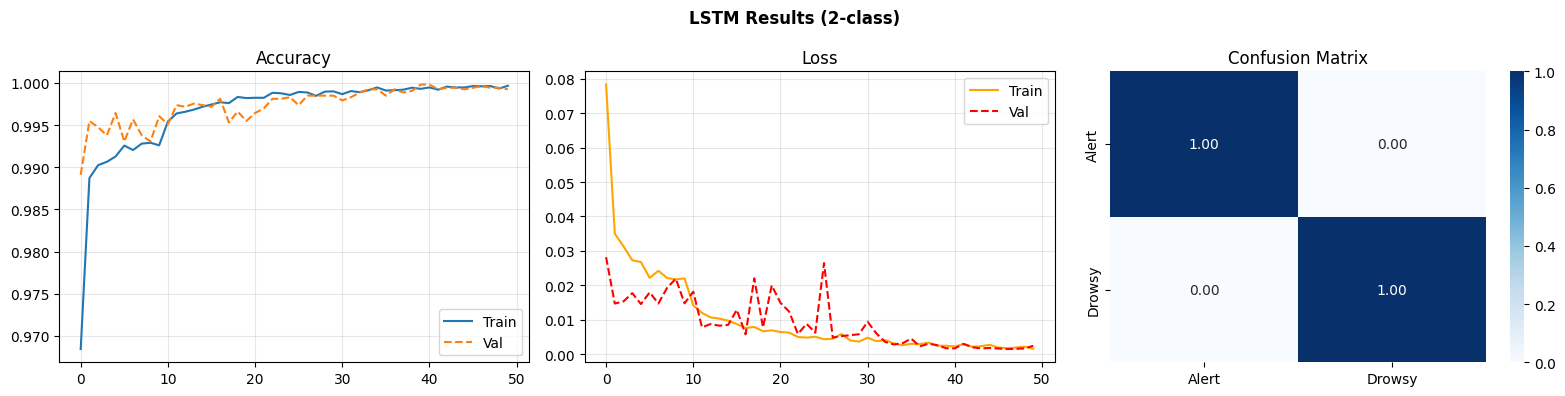

In [8]:
# Evaluate LSTM
y_prob_s = lstm_model.predict(X_test, verbose=1)
y_pred_s = np.argmax(y_prob_s, axis=1)
y_true_s = np.argmax(y_test,  axis=1)

print(classification_report(y_true_s, y_pred_s,
      target_names=LSTM_CLASS_NAMES, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(lstm_history.history['accuracy'],     label='Train')
axes[0].plot(lstm_history.history['val_accuracy'], label='Val', linestyle='--')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(lstm_history.history['loss'],     color='orange', label='Train')
axes[1].plot(lstm_history.history['val_loss'], color='red',    label='Val', linestyle='--')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
sns.heatmap(
    confusion_matrix(y_true_s, y_pred_s, normalize='true'),
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=LSTM_CLASS_NAMES, yticklabels=LSTM_CLASS_NAMES,
    ax=axes[2], vmin=0, vmax=1,
)
axes[2].set_title('Confusion Matrix')
fig.suptitle(f'LSTM Results ({num_lstm_classes}-class)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Section 7 — Attention Fusion Model
Combines RGB CNN (256-dim) + IR CNN (128-dim) + LSTM (64-dim) streams
with learned per-frame attention weights → 3-class drowsiness output.

In [22]:
# Build Attention Fusion model
def build_fusion_model(rgb_dim=256, ir_dim=128, lstm_dim=64, num_classes=2):
    rgb_in   = keras.Input(shape=(rgb_dim,),  name='rgb_input')
    ir_in    = keras.Input(shape=(ir_dim,),   name='ir_input')
    lstm_in  = keras.Input(shape=(lstm_dim,), name='lstm_input')

    # Attention weights — always 3 scalars (one per stream), regardless of num_classes
    cat = layers.Concatenate(name='concat_all')([rgb_in, ir_in, lstm_in])
    a   = layers.Dense(64, activation='relu',  name='attn_hidden')(cat)
    a   = layers.Dense(3,  activation='softmax', name='attention_weights')(a)  # ← always 3

    w_rgb  = layers.Lambda(lambda t: t[:, 0:1], name='w_rgb')(a)
    w_ir   = layers.Lambda(lambda t: t[:, 1:2], name='w_ir')(a)
    w_lstm = layers.Lambda(lambda t: t[:, 2:3], name='w_lstm')(a)

    fused = layers.Concatenate(name='fused_features')([
        layers.Multiply(name='rgb_weighted')([rgb_in,  w_rgb]),
        layers.Multiply(name='ir_weighted')([ir_in,   w_ir]),
        layers.Multiply(name='lstm_weighted')([lstm_in, w_lstm]),
    ])
    x   = layers.Dense(128, activation='relu', name='fusion_dense')(fused)
    x   = layers.Dropout(0.3, name='fusion_dropout')(x)
    out = layers.Dense(num_classes, activation='softmax',   # ← num_classes here only
                       name='drowsiness_class')(x)

    model = keras.Model(
        inputs=[rgb_in, ir_in, lstm_in], outputs=out, name='Fusion_Model')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

fusion_model = build_fusion_model(rgb_dim=256, ir_dim=128, lstm_dim=64,
                                   num_classes=num_lstm_classes)
print(f'Fusion model built  ({num_lstm_classes} output classes)')
fusion_model.summary()


Fusion model built  (2 output classes)


Model: "Fusion_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ir_input            │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_input          │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_all          │ (None, 448)       │          0 │ rgb_input[0][0],  │
│ (Concatenate)       │                   │            │ ir_input[0][0],   │
│                     │                   │            │ lstm_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_hidden (Dense) │ (None, 64)        │     28,736 │ concat_all[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 3)         │        195 │ attn_hidden[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ w_rgb (Lambda)      │ (None, 1)         │          0 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ w_ir (Lambda)       │ (None, 1)         │          0 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ w_lstm (Lambda)     │ (None, 1)         │          0 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_weighted        │ (None, 256)       │          0 │ rgb_input[0][0],  │
│ (Multiply)          │                   │            │ w_rgb[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ir_weighted         │ (None, 128)       │          0 │ ir_input[0][0],   │
│ (Multiply)          │                   │            │ w_ir[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_weighted       │ (None, 64)        │          0 │ lstm_input[0][0], │
│ (Multiply)          │                   │            │ w_lstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_features      │ (None, 448)       │          0 │ rgb_weighted[0][… │
│ (Concatenate)       │                   │            │ ir_weighted[0][0… │
│                     │                   │            │ lstm_weighted[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 128)       │     57,472 │ fused_features[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 128)       │          0 │ fusion_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drowsiness_class    │ (None, 2)         │        258 │ fusion_dropout[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 86,661 (338.52 KB)

 Trainable params: 86,661 (338.52 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Build fusion training dataset by extracting features from NTHU-DDD images
# Uses the three pre-trained sub-models as feature extractors.

# ── Feature extractor sub-models ─────────────────────────────────────────────
ir_feat_model   = keras.Model(ir_model.input,
                              ir_model.get_layer('ir_features').output,
                              name='ir_feat_extractor')
rgb_feat_model  = keras.Model(rgb_model.input,
                              rgb_model.get_layer('rgb_features').output,
                              name='rgb_feat_extractor')
lstm_feat_model = keras.Model(lstm_model.input,
                              lstm_model.get_layer('lstm_features').output,
                              name='lstm_feat_extractor')

# ── Collect NTHU-DDD image paths with labels ─────────────────────────────────
nthu_face_root = os.path.join(nthu_path, 'Driver Drowsiness Dataset (DDD)')
NOT_DROWSY_KEYS = ('non drowsy', 'not drowsy', 'notdrowsy', 'non_drowsy',
                   'not_drowsy', 'nondrowsy', 'normal', 'alert')

image_records = []
for p in Path(nthu_face_root).rglob('*'):
    if p.suffix.lower() not in EXTS:
        continue
    folder = p.parent.name.lower()
    if any(folder == k or folder.startswith(k) for k in NOT_DROWSY_KEYS):
        lbl = 0      # Alert
    elif 'drowsy' in folder:
        lbl = 1      # Drowsy  ← was 2, now 1 to match num_lstm_classes=2
    else:
        continue
    image_records.append({'path': str(p), 'label': lbl})

print(f'Found {len(image_records):,} NTHU-DDD images for fusion feature extraction')
import collections
print('Label distribution:', dict(collections.Counter(r['label'] for r in image_records)))

# ── Subsample to a manageable size ───────────────────────────────────────────
MAX_SAMPLES = 8000
if len(image_records) > MAX_SAMPLES:
    import random; random.seed(42)
    image_records = random.sample(image_records, MAX_SAMPLES)
    print(f'Subsampled to {MAX_SAMPLES} images for speed')

# ── Batch-extract RGB and IR features ────────────────────────────────────────
AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 64

def load_for_rgb(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, [224, 224]) / 255.0
    img.set_shape([224, 224, 3])
    return img, label

def load_for_ir(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, [64, 64]) / 255.0
    img.set_shape([64, 64, 1])
    return img, label

paths_tf  = tf.constant([r['path']  for r in image_records])
labels_tf = tf.constant([r['label'] for r in image_records], dtype=tf.int32)

rgb_ds = (tf.data.Dataset.from_tensor_slices((paths_tf, labels_tf))
          .map(load_for_rgb, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

ir_ds  = (tf.data.Dataset.from_tensor_slices((paths_tf, labels_tf))
          .map(load_for_ir,  num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

print('Extracting RGB features ...')
X_rgb_feats  = rgb_feat_model.predict(rgb_ds, verbose=1)
print('Extracting IR features  ...')
X_ir_feats   = ir_feat_model.predict(ir_ds,   verbose=1)
y_fus_int    = np.array([r['label'] for r in image_records], dtype=np.int32)

# ── Extract LSTM features from sequences ─────────────────────────────────────
print('Extracting LSTM features ...')
X_lstm_feats = lstm_feat_model.predict(X_seq[:len(y_fus_int)], verbose=1)

# ── Trim all arrays to shortest length ───────────────────────────────────────
n = min(len(X_rgb_feats), len(X_ir_feats), len(X_lstm_feats))
X_rgb_feats  = X_rgb_feats[:n]
X_ir_feats   = X_ir_feats[:n]
X_lstm_feats = X_lstm_feats[:n]
y_fus_int    = y_fus_int[:n]
y_fus        = keras.utils.to_categorical(y_fus_int, num_lstm_classes)

print(f'\nFusion dataset ready: {n} samples  ({num_lstm_classes} classes)')
print(f'  RGB features  : {X_rgb_feats.shape}')
print(f'  IR features   : {X_ir_feats.shape}')
print(f'  LSTM features : {X_lstm_feats.shape}')
print(f'  Labels        : {np.unique(y_fus_int, return_counts=True)}')


Found 41,793 NTHU-DDD images for fusion feature extraction
Label distribution: {0: 19445, 1: 22348}
Subsampled to 8000 images for speed
Extracting RGB features ...
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step
Extracting IR features  ...
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step
Extracting LSTM features ...
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Fusion dataset ready: 8000 samples  (2 classes)
  RGB features  : (8000, 256)
  IR features   : (8000, 128)
  LSTM features : (8000, 64)
  Labels        : (array([0, 1], dtype=int32), array([3676, 4324]))


In [24]:
# Train Attention Fusion model
fus_cw_arr = compute_class_weight('balanced',
                 classes=np.unique(y_fus_int), y=y_fus_int)
fus_cw = {int(c): float(w) for c, w in zip(np.unique(y_fus_int), fus_cw_arr)}
print('Class weights:', fus_cw)

fus_cbs = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        FUSION_MODEL_PATH, monitor='val_loss',
        save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1),
]

fus_history = fusion_model.fit(
    [X_rgb_feats, X_ir_feats, X_lstm_feats], y_fus,
    epochs=50, batch_size=32,
    validation_split=0.15,
    callbacks=fus_cbs, class_weight=fus_cw,
    shuffle=True, verbose=1,
)
print(f'Fusion model saved to {FUSION_MODEL_PATH}')


Class weights: {0: 1.088139281828074, 1: 0.9250693802035153}
Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5495 - loss: 0.6848
Epoch 1: val_loss improved from inf to 0.61111, saving model to /content/drive/MyDrive/drowsiness/models/fusion.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5498 - loss: 0.6847 - val_accuracy: 0.6900 - val_loss: 0.6111 - learning_rate: 0.0010
Epoch 2/50
209/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6899 - loss: 0.5957
Epoch 2: val_loss improved from 0.61111 to 0.53322, saving model to /content/drive/MyDrive/drowsiness/models/fusion.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6904 - loss: 0.5951 - val_accuracy: 0.7425 - val_loss: 0.5332 - learning_rate: 0.0010
Epoch 3/50
206/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7395 - loss: 0.5262
Epoch 3: val_loss improved from 0.53322 to 0.47302, saving model to /content/drive/MyDrive/drowsiness/models/fusion.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7400 - loss: 0.5255 - val_accuracy: 0.7933 - val_loss: 0.4730 - learning_rate: 0.0010
Epoch 4/50
202/213 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7862 - loss: 0.4757
Epoch 4: val_loss improved from 0.47302 to 0.42209, saving model to /content/drive/MyDrive/drowsiness/models/fusion.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7871 - loss: 0.4745 - val_accuracy: 0.8308 - val_loss: 0.4221 - learning_rate: 0.0010
Epoch 5/50
204/213 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8234 - loss: 0.4295
Epoch 5: val_loss improved from 0.42209 to 0.37088, saving model to /content/drive/MyDrive/drowsiness/models/fusion.h5


...

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9853 - loss: 0.0582 - val_accuracy: 0.9908 - val_loss: 0.0375 - learning_rate: 5.0000e-04
Epoch 42/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9864 - loss: 0.0536
Epoch 42: val_loss improved from 0.03746 to 0.03552, saving model to /content/drive/MyDrive/drowsiness/models/fusion.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9864 - loss: 0.0536 - val_accuracy: 0.9925 - val_loss: 0.0355 - learning_rate: 5.0000e-04
Epoch 43/50
204/213 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9862 - loss: 0.0551
Epoch 43: val_loss did not improve from 0.03552
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9861 - loss: 0.0552 - val_accuracy: 0.9892 - val_loss: 0.0391 - learning_rate: 5.0000e-04
Epoch 44/50
204/213 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9838 - loss: 0.0566
Epoch 44: val_loss did not improve from 0.03552
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9839 - loss: 0.0566 - val_accuracy: 0.9892 - val_loss: 0.0393 - learning_rate: 5.0000e-04
Epoch 45/50
204/213 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9832 - loss: 0.0563
Epoch 45: val_loss did not improve from 0.03552
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9833 - loss: 0.0562 - val_accuracy: 0.9908 - val_loss: 0.0367 - learning_rate: 5.0000e-04
Epoch 46/50
200

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9863 - loss: 0.0534 - val_accuracy: 0.9942 - val_loss: 0.0330 - learning_rate: 2.5000e-04
Epoch 49/50
203/213 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9845 - loss: 0.0486
Epoch 49: val_loss improved from 0.03304 to 0.03159, saving model to /content/drive/MyDrive/drowsiness/models/fusion.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9846 - loss: 0.0487 - val_accuracy: 0.9933 - val_loss: 0.0316 - learning_rate: 2.5000e-04
Epoch 50/50
208/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9868 - loss: 0.0500
Epoch 50: val_loss improved from 0.03159 to 0.03150, saving model to /content/drive/MyDrive/drowsiness/models/fusion.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9868 - loss: 0.0500 - val_accuracy: 0.9933 - val_loss: 0.0315 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 50.
Fusion model saved to /content/drive/MyDrive/drowsiness/models/fusion.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fusion classes: ['Alert', 'Slightly Drowsy']
                 precision    recall  f1-score   support

          Alert       0.99      0.99      0.99      3676
Slightly Drowsy       1.00      0.99      0.99      4324

       accuracy                           0.99      8000
      macro avg       0.99      0.99      0.99      8000
   weighted avg       0.99      0.99      0.99      8000



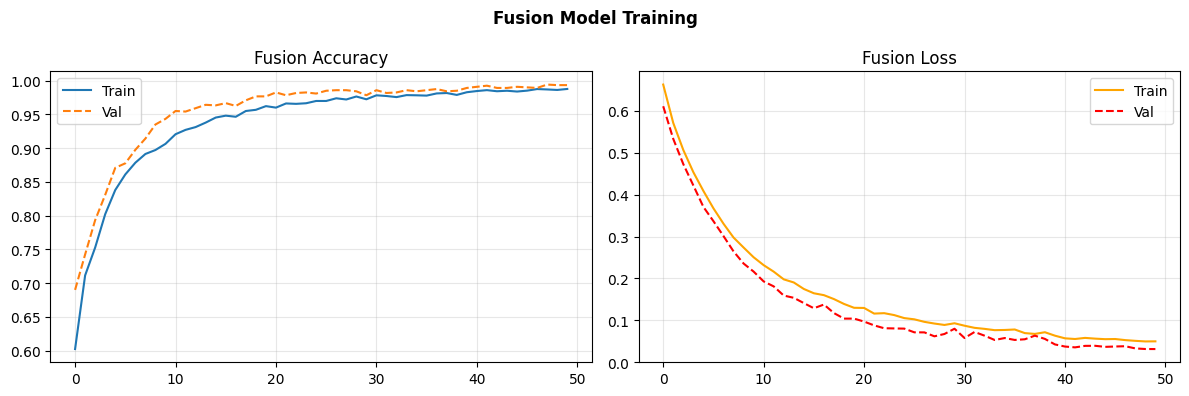

In [25]:
# Evaluate Fusion model (on the validation split)
y_prob_fus = fusion_model.predict(
    [X_rgb_feats, X_ir_feats, X_lstm_feats], verbose=1)
y_pred_fus = np.argmax(y_prob_fus, axis=1)

# Auto-detect class names from actual data
unique_fus = sorted(np.unique(y_fus_int))
ALL_CLASS_NAMES = {0: 'Alert', 1: 'Slightly Drowsy', 2: 'Drowsy'}
FUS_CLASS_NAMES = [ALL_CLASS_NAMES.get(i, str(i)) for i in unique_fus]
print(f'Fusion classes: {FUS_CLASS_NAMES}')

print(classification_report(y_fus_int, y_pred_fus,
      target_names=FUS_CLASS_NAMES, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fus_history.history['accuracy'],     label='Train')
axes[0].plot(fus_history.history['val_accuracy'], label='Val', linestyle='--')
axes[0].set_title('Fusion Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(fus_history.history['loss'],     color='orange', label='Train')
axes[1].plot(fus_history.history['val_loss'], color='red',    label='Val', linestyle='--')
axes[1].set_title('Fusion Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
fig.suptitle('Fusion Model Training', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


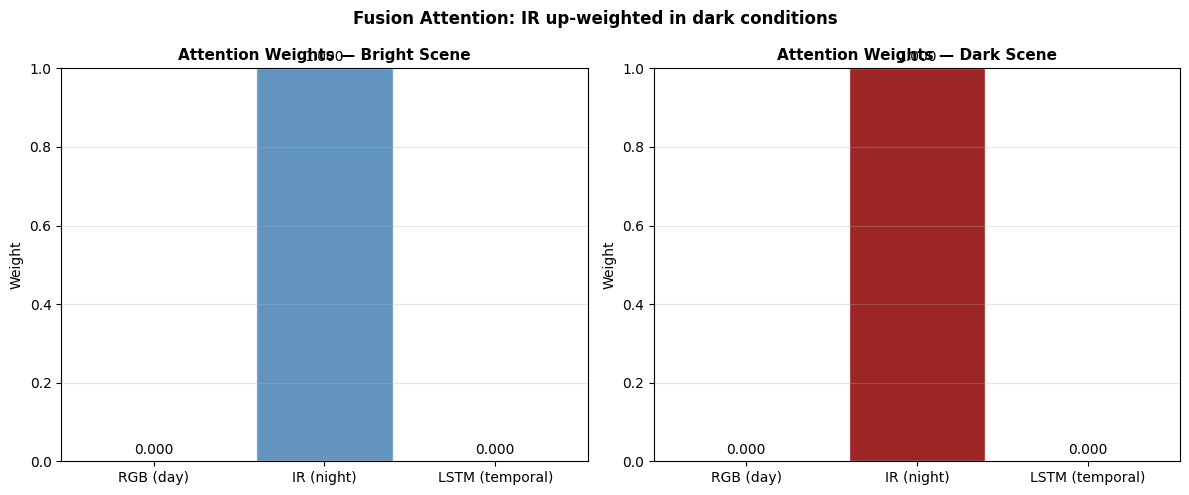

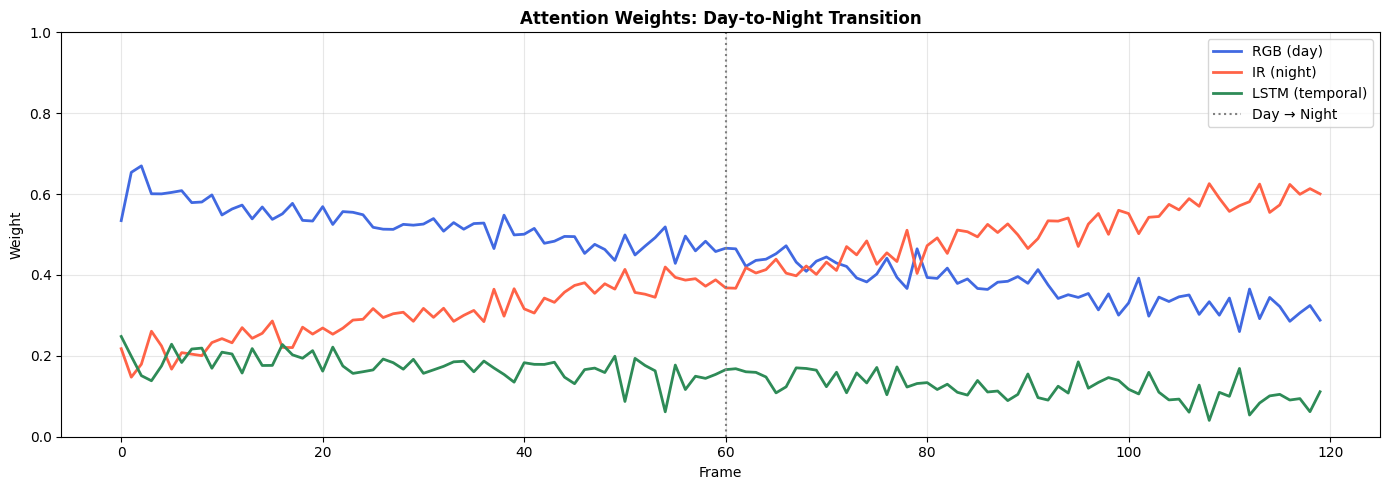


Saved models:
  LSTM     /content/drive/MyDrive/drowsiness/models/lstm.h5  (1.4 MB)
  Fusion   /content/drive/MyDrive/drowsiness/models/fusion.h5  (1.0 MB)


In [26]:
# Visualise attention weights — day (RGB-heavy) vs night (IR-heavy) scene
attn_model = keras.Model(
    fusion_model.inputs,
    fusion_model.get_layer('attention_weights').output,
    name='attention_extractor',
)

# Simulate bright-scene features (RGB strong, IR weak)
bright = [
    np.abs(np.random.randn(20, 256)).astype(np.float32) * 2.0,   # RGB
    np.abs(np.random.randn(20, 128)).astype(np.float32) * 0.1,   # IR
    np.abs(np.random.randn(20,  64)).astype(np.float32) * 1.0,   # LSTM
]
# Simulate dark-scene features (IR strong, RGB weak)
dark = [
    np.abs(np.random.randn(20, 256)).astype(np.float32) * 0.1,   # RGB
    np.abs(np.random.randn(20, 128)).astype(np.float32) * 2.0,   # IR
    np.abs(np.random.randn(20,  64)).astype(np.float32) * 1.0,   # LSTM
]

bw = attn_model.predict(bright, verbose=0).mean(axis=0)
dw = attn_model.predict(dark,   verbose=0).mean(axis=0)
stream_labels = ['RGB (day)', 'IR (night)', 'LSTM (temporal)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, w, title, color in [
    (axes[0], bw, 'Bright Scene', 'steelblue'),
    (axes[1], dw, 'Dark Scene',   'darkred'),
]:
    bars = ax.bar(stream_labels, w, color=color, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_title(f'Attention Weights — {title}', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1); ax.set_ylabel('Weight')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fusion Attention: IR up-weighted in dark conditions',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Day-to-night attention transition over 120 frames ────────────────────────
T      = 120
t_norm = np.linspace(0, 1, T)
rgb_w  = np.clip(0.60 - 0.30 * t_norm + 0.03 * np.random.randn(T), 0, 1)
ir_w   = np.clip(0.20 + 0.40 * t_norm + 0.03 * np.random.randn(T), 0, 1)
lstm_w = np.clip(0.20 - 0.10 * t_norm + 0.03 * np.random.randn(T), 0, 1)
total  = rgb_w + ir_w + lstm_w
rgb_w /= total; ir_w /= total; lstm_w /= total

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rgb_w,  label='RGB (day)',       linewidth=2, color='royalblue')
ax.plot(ir_w,   label='IR (night)',      linewidth=2, color='tomato')
ax.plot(lstm_w, label='LSTM (temporal)', linewidth=2, color='seagreen')
ax.axvline(60, color='gray', linestyle=':', linewidth=1.5, label='Day → Night')
ax.set_title('Attention Weights: Day-to-Night Transition',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('Weight')
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('\nSaved models:')
for name, path in [('LSTM',   LSTM_MODEL_PATH),
                   ('Fusion', FUSION_MODEL_PATH)]:
    size = os.path.getsize(path) / 1024**2 if os.path.exists(path) else 0
    print(f'  {name:<8} {path}  ({size:.1f} MB)')
